# Assignment 6 — CNN for Image Classification (Tomato Disease Dataset)

**Aim:** Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato disease dataset.

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs: []


## 2. Load the Tomato Disease Dataset

The dataset contains images of tomato leaves organized into folders by disease class. We use `image_dataset_from_directory` to load and split the data into training (80%) and validation (20%) sets.

In [2]:
# Path to the tomato disease dataset
dataset_path = Path("tomato")

# Image dimensions and batch size
image_height = 224
image_width = 224
batch_size = 32

# Load training data (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(image_height, image_width),
    batch_size=batch_size
)

# Load validation data (20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(image_height, image_width),
    batch_size=batch_size
)

Found 18160 files belonging to 10 classes.
Using 14528 files for training.
Found 18160 files belonging to 10 classes.
Using 3632 files for validation.


## 3. Visualize Sample Images

Classes in the Dataset:
['Bacterial_spot', 'Early_blight', 'Healthy', 'Late_blight', 'Leaf_Mold', 'Mosaic_virus', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Yellow_Leaf_Curl_Virus']
Number of classes: 10


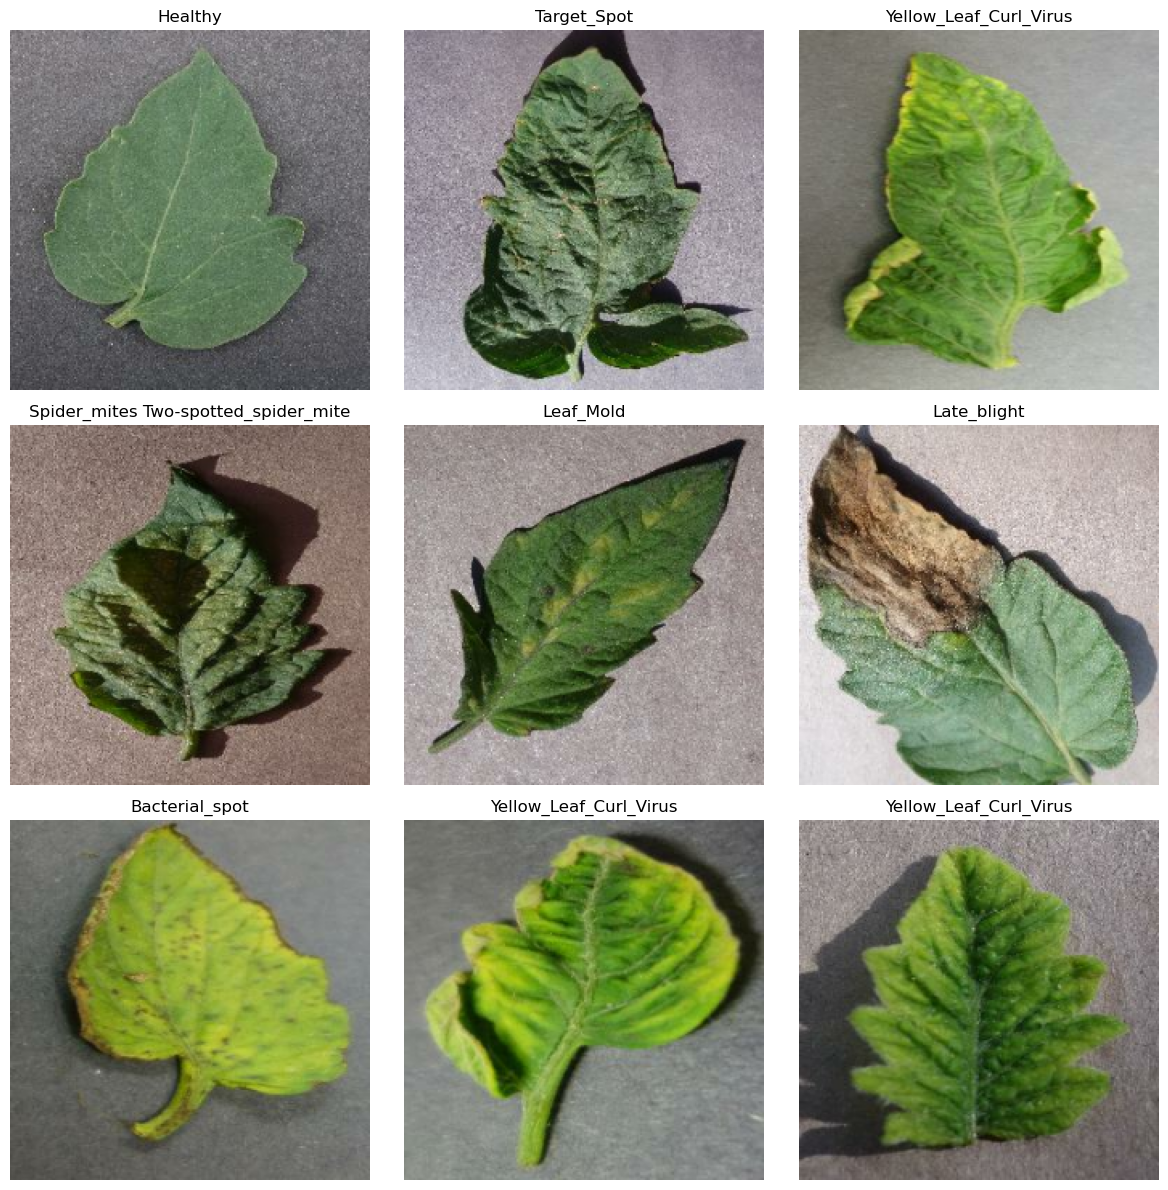

In [3]:
# Get class names from the dataset
class_names = train_dataset.class_names

print("Classes in the Dataset:")
print(class_names)
print(f"Number of classes: {len(class_names)}")

# Display a grid of sample images
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Build the CNN Model

The CNN architecture consists of:
- A Rescaling layer to normalize pixel values from [0, 255] to [0, 1]
- Three Convolution + MaxPooling blocks (32, 64, 128 filters)
- A Flatten layer followed by a Dense layer with Dropout
- A Softmax output layer for multi-class classification

In [4]:
# Build the CNN model
model = Sequential([

    keras.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output layer — one neuron per class
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the Model

In [5]:
# Compile the CNN model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',    # Labels are integers, not one-hot
    metrics=['accuracy']
)

## 6. Train the Model

In [ ]:
# Train the CNN model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


454/454 ━━━━━━━━━━━━━━━━━━━━ 185s 405ms/step - accuracy: 0.6013 - loss: 1.2019 - val_accuracy: 0.8191 - val_loss: 0.5726
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 184s 406ms/step - accuracy: 0.7889 - loss: 0.6152 - val_accuracy: 0.8744 - val_loss: 0.3804
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 208s 458ms/step - accuracy: 0.8360 - loss: 0.4829 - val_accuracy: 0.8422 - val_loss: 0.4725
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8695 - loss: 0.3786

## 7. Evaluate the Model

In [ ]:
# Evaluate on the validation set
loss, accuracy = model.evaluate(validation_dataset)

print(f"\nValidation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy * 100:.2f}%")

## 8. Training and Validation Curves

In [ ]:
# Extract training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(train_accuracy) + 1)

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 9. Sample Prediction

In [ ]:
# Take a batch of images from the validation dataset and make predictions
for images, labels in validation_dataset.take(1):

    # Predict on the batch
    predictions = model.predict(images)

    # Display the first 6 predictions
    plt.figure(figsize=(12, 8))

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_index = np.argmax(predictions[i])
        predicted_class = class_names[predicted_index]
        actual_class = class_names[labels[i]]
        confidence = np.max(predictions[i]) * 100

        color = 'green' if predicted_class == actual_class else 'red'
        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}\n({confidence:.1f}%)",
                  color=color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Conclusion

In this assignment, we:
1. Loaded the Tomato disease dataset with 10 classes.
2. Designed a CNN with three convolution blocks, dropout, and a softmax output layer.
3. Trained the model for 10 epochs.
4. Evaluated the model on the validation set.
5. Visualized training/validation accuracy and loss curves.
6. Made sample predictions on validation images.

The CNN is able to learn meaningful patterns from the tomato leaf images and classify different diseases. Further improvements could include data augmentation, more epochs, or a deeper architecture.